# Tarea 2: Aproximacion con SVD y aplicaciones 
Parte 2 , Aplicacion SVD a un dataset de imagenes

Para la ejecucion de este proyecto solo se debe hacer la importacion de las librerias contenidas en el requirements.txt

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd
import pandas as pd
from sklearn.datasets import fetch_openml

Para la elavoracion de esta parte de la tarea se decidio usar el dataset de Fashion-MNIST , este contiene 70000 imagenes de prendas o ropas de 28 x 28 pixeles , tal que podemos representar cada imagen como un vector de 784 dimensiones

In [ ]:
#Descarga de imagenes de Fashion-MNIST
fashion_minst = fetch_openml('Fashion-MNIST', version=1)
imagenes = fashion_minst.data
etiquetas = fashion_minst.target
print(imagenes.shape)
print(etiquetas.shape)

(70000, 784)
(70000,)


Podemos notar entonces que la descarga del dataset dado es de dimension 70000 x 784, congruente con los datos, tal que tenemos datos que podemos transformar a una matriz de 70000 x 784 dimensiones , esto se aplicara usando la funcion integrada a sklearn de "to_numpy()" para poder tener buenos medios para trabajar

In [89]:
matriz = imagenes.to_numpy()
print(matriz.shape)
print(np.linalg.matrix_rank(matriz))

(70000, 784)
784


Notar que nuestra matriz tiene un rango de 784 , es decir , esto significa que nos dara 784 valores  y vectores singulares distintos

## Creacion svd :

In [90]:
matriz_c = matriz - np.mean(matriz, axis=0)
U, S, Vt = np.linalg.svd(matriz_c , full_matrices=False)

In [91]:
varianza = S**2 / (S**2).sum()
def graf_var_prop(num_elem):
    
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(S[:num_elem], 'o-', label='Valores singulares')
    plt.title(f'Primeros {num_elem} Valores singulares')
    plt.xlabel('Índice')
    plt.ylabel('Valor singular')
    
    plt.subplot(1, 2, 2)
    plt.bar(range(1, num_elem + 1), varianza[:num_elem], alpha=0.7, label='Varianza explicada')
    plt.title(f'Varianza explicada por los primeros {num_elem} componentes')
    plt.xlabel('Componente principal')
    plt.ylabel('Varianza explicada')                              
    plt.tight_layout()
    plt.show()
    
print(f"Varianza explicada — PC1: {varianza[0]:.1%}  |  PC2: {varianza[1]:.1%}  |  Total: {varianza[:2].sum():.1%}")

Varianza explicada — PC1: 29.1%  |  PC2: 17.7%  |  Total: 46.8%


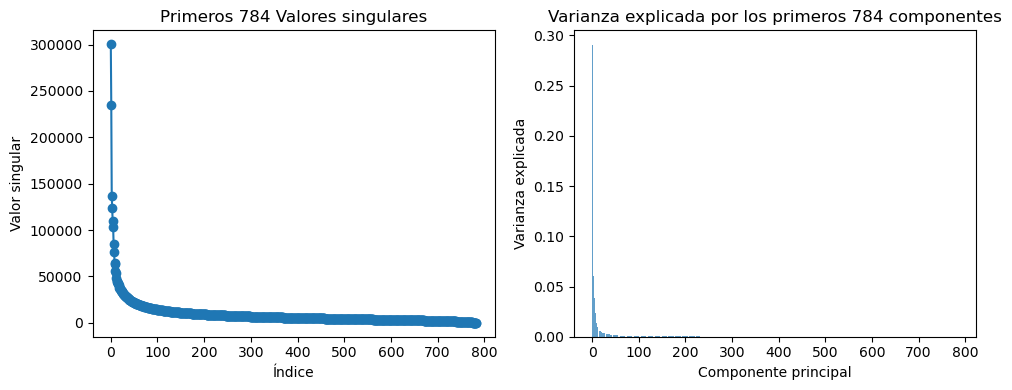

In [92]:
graf_var_prop(784)

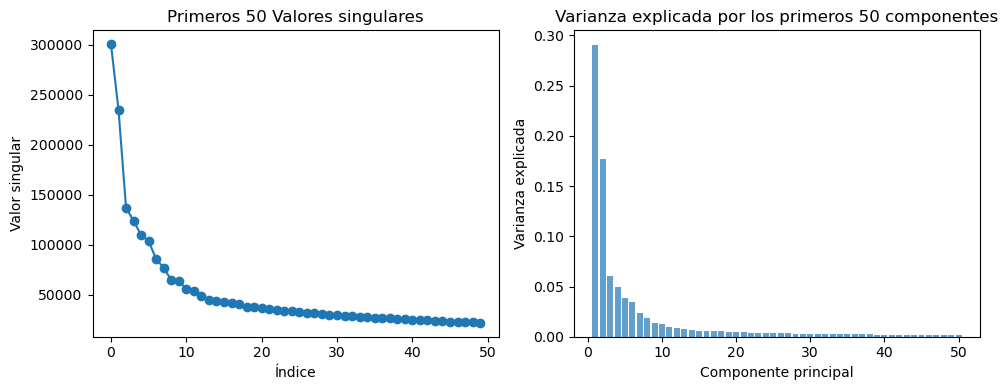

In [93]:
graf_var_prop(50)

## Creacion Eigen Imagenes:

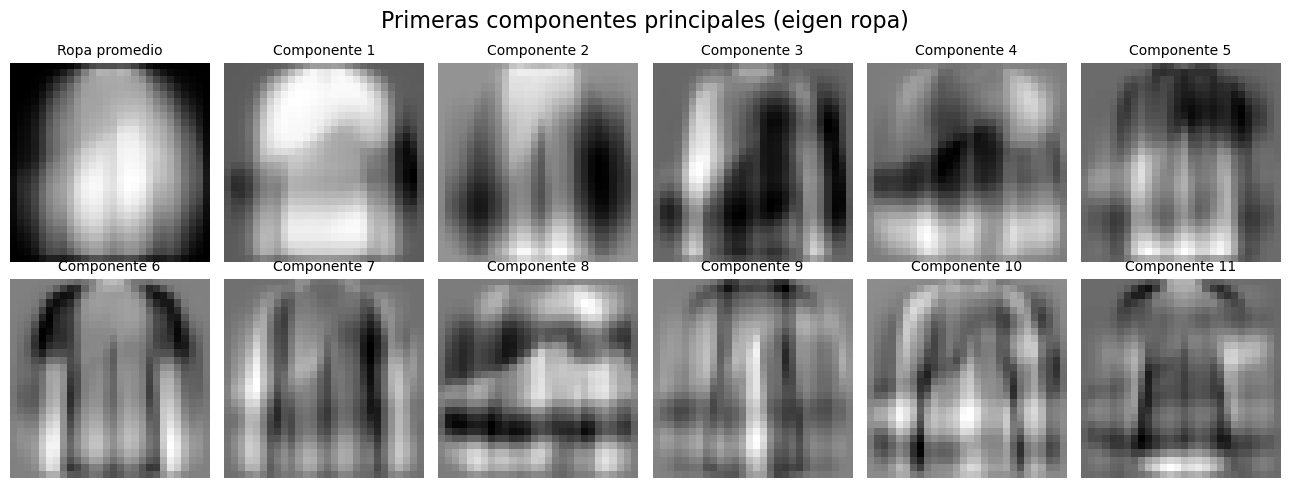

In [94]:
n_eigen = 11
fig , axes = plt.subplots(2, 6, figsize=(13, 5))

# ropa promedio "eigen ropa fuaaa"

ropa_promedio = np.mean(matriz, axis=0).reshape(28, 28)

axes[0, 0].imshow(ropa_promedio, cmap='gray')
axes[0, 0].set_title('Ropa promedio' , fontsize = 10)
axes[0, 0].axis('off')

for i , ax in enumerate(axes.flat[1:n_eigen + 1]):
    eigen_ropa = Vt[i].reshape(28, 28)
    ax.imshow(eigen_ropa, cmap='gray')
    ax.set_title(f"Componente {i+1}", fontsize=10)
    ax.axis('off')
    
for ax in axes.flat[n_eigen + 1:]:
    ax.axis('off')

fig.suptitle('Primeras componentes principales (eigen ropa)', fontsize=16)
plt.tight_layout()
plt.show()

Me gustaria remarcar hechos interesantes, podemos notar que se vislumbran cosas como que tanto la componente 1, 6 , 7 9 10 y 11 parecen ser camisas, el resto es una extraña superposicion entre diferentes prendas, por ejemplo el 4 parece , en cierta perspectiva, un zapato, y la componente 8 no es identificable, pareciendo mas una mandibula que otra cosa

Ahora reconstruiremos ciertas imagenes usando diversa cantidad de vectores singulares, usaremos entre 1 a 784 vectores singulares esto buscando ver la transformacion a imagenes reconocibles a lo largo de la seleccion de mas cantidad de vectores usando la representacion sumatoria de la forma:

$$\hat{x}_k = \bar{x} + \sum_{i=1}^{k} z_i v_i, \qquad z_i = \tilde{x}^\top v_i$$

Tal que $ \hat{x}_k $ es la aproximacion de k vectores singulares de cada vector original , $ \bar{x}$ es el vector "central" nacido de la media de todos los vectores , $z_i$ representa el "peso" de cada vector , es decir, cuanto de la imagen original representa cada componente $v_i$ es el vector singular asocido,es decir, nuestra "eigen ropa", tal que podemos notar que la suma de todas las "eigen ropas" son Exactamente lo mismo al vector original que buscamos recomponer

usando como indices: [57274, 43853, 50509, 28893, 386, 11182, 66293, 12277, 68553, 24589]


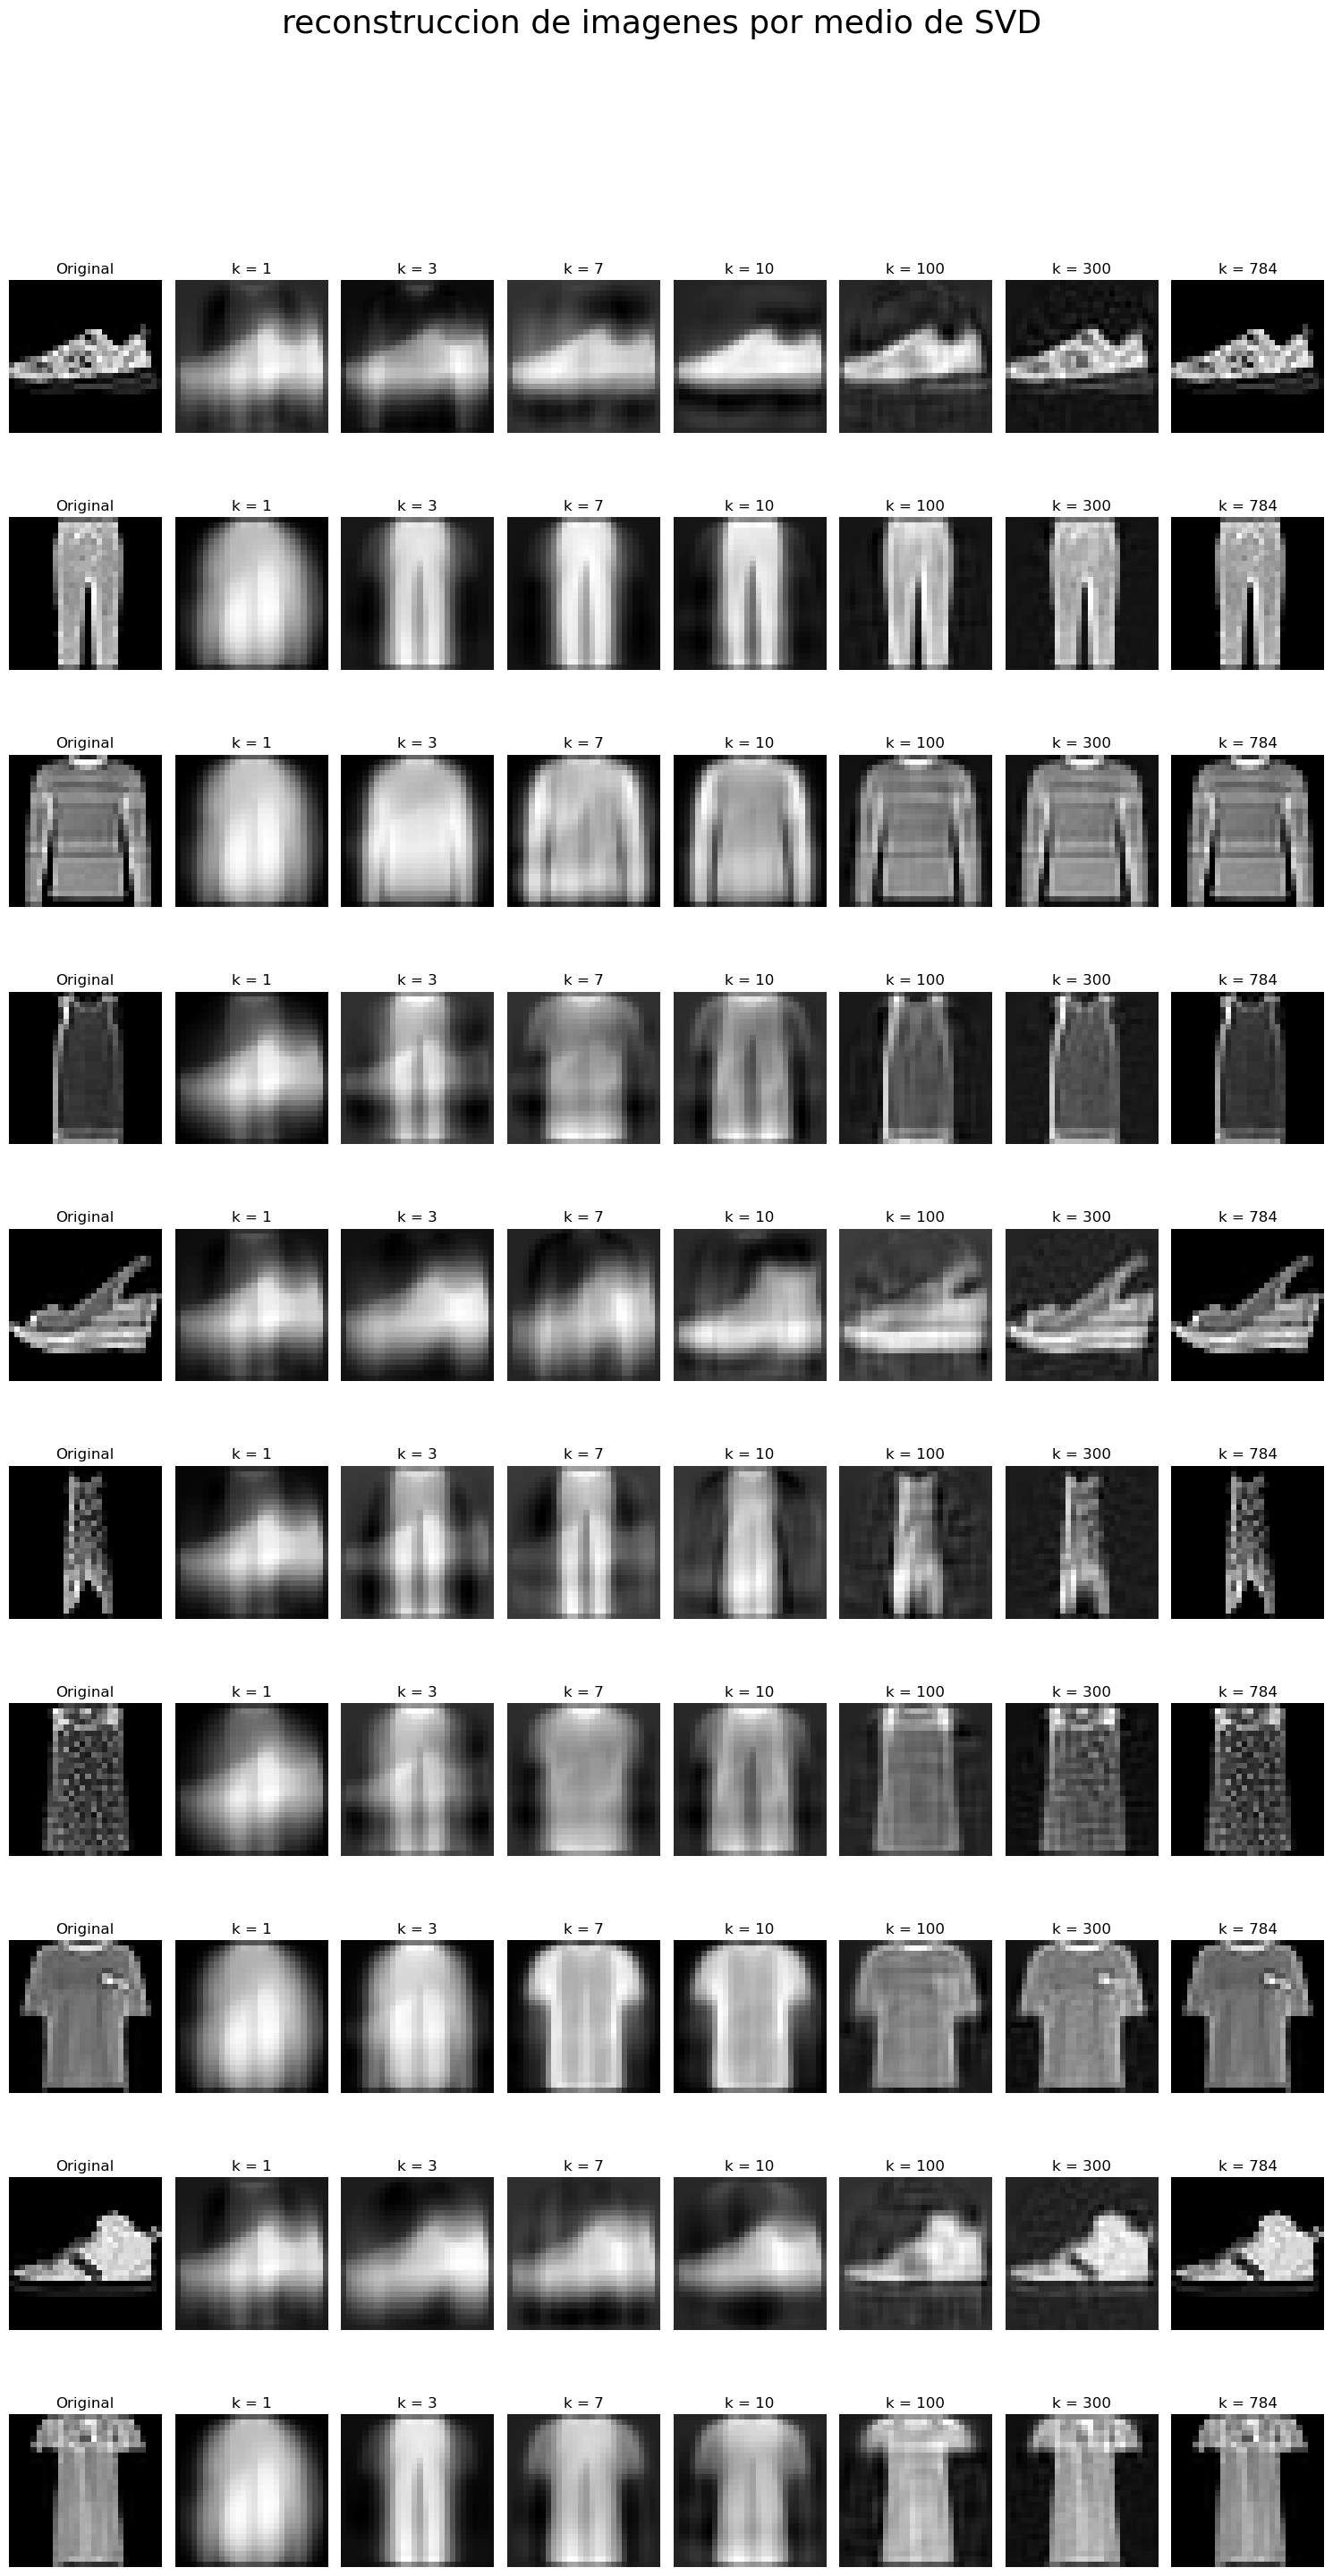

In [96]:
seed = 67
np.random.seed(seed)

# Valores de k componentes a utilizar para la aproximación
k_values = [1, 3, 7, 10, 100 , 300 , 784]

indices = np.random.choice(matriz.shape[0], size=10, replace=False).tolist()
print("usando como indices:" , indices)
num_imagenes = len(indices)
media = np.mean(matriz, axis=0) #para "des centrar" nuestros vectores


fig , axes = plt.subplots(num_imagenes, len(k_values) + 1, figsize=(15, 3 * num_imagenes))
fig.suptitle("reconstruccion de imagenes por medio de SVD " , fontsize = 26)

for i , idx in enumerate(indices):
    imagen_org = matriz[idx].reshape(28, 28)
    axes[i, 0].imshow(imagen_org, cmap='gray')
    axes[i, 0].set_title("Original")
    axes[i, 0].axis('off')
    #construccion por svd
    for j , k in enumerate(k_values):
        reconstruccion_k = np.dot(U[idx, :k] * S[:k], Vt[:k, :]) + media
        img_reconstruida = reconstruccion_k.reshape(28, 28)
        axes[i, j + 1].imshow(img_reconstruida, cmap='gray')
        axes[i, j + 1].set_title(f"k = {k}")
        axes[i, j + 1].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()
        

Como analisis podemos notar que todas las imagenes van asimilandose a la original mientras mas valores singulares se tiene, se puede notar como gran parte de las prendas ya tienen un parecido en su primera componente, con gran mayoria haciendose reconocible en las primeras 3 a 7 componentes, y con un asemejo bastante importante en los casos donde usamos 100 y 300 variantes , ademas , podemos notar como no hay ningun tipo de perdida de informacion si usamos 784 componentes, es decir, y como es esperable en este caso, todos los vectores se puede recuperar si usamos la base completa